In [4]:
#importing libraries
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
pio.templates

Templates configuration
-----------------------
    Default template: 'plotly'
    Available templates:
        ['ggplot2', 'seaborn', 'simple_white', 'plotly',
         'plotly_white', 'plotly_dark', 'presentation', 'xgridoff',
         'ygridoff', 'gridon', 'none']

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

In [28]:
#Loading the data
data=pd.read_excel(r"C:\Users\Hp\Downloads\Nairobi_Rental_10000_Realistic_Rent_Distribution.xlsx")
print(data.head(100))          

     ID     Estate         SubCounty           Ward  Rent_KES Property_Type  \
0     1   Pipeline     Embakasi East  Upper Savanna     20500        Studio   
1     2     Kayole  Embakasi Central         Kayole      8000     Bedsitter   
2     3  Zimmerman          Roysambu       Roysambu     21500        Studio   
3     4     Kibera             Kibra     Laini Saba      3500   Single Room   
4     5     Kayole  Embakasi Central         Kayole     13000     Bedsitter   
..  ...        ...               ...            ...       ...           ...   
95   96   Roysambu          Roysambu       Roysambu     39500     Apartment   
96   97    South C           Langata   Nairobi West     70000     Apartment   
97   98    Mathare           Ruaraka  Mathare North      7500   Single Room   
98   99    South B           Langata        South B     23500        Studio   
99  100   Roysambu          Roysambu       Roysambu     14000     Bedsitter   

    Bedrooms  Bathrooms  
0          1          1  

In [29]:
#Check for missing values
data.isnull().sum()

ID               0
Estate           0
SubCounty        0
Ward             0
Rent_KES         0
Property_Type    0
Bedrooms         0
Bathrooms        0
dtype: int64

In [30]:

# Number of duplicate rows
data.duplicated().sum()

np.int64(0)

In [15]:
#checking for inconsistencies
for col in data.select_dtypes(include='object'):
    print(f"\n{col}")
    print(data[col].unique())


Estate
['Pipeline' 'Kayole' 'Zimmerman' 'Kibera' 'Karen' 'Runda' 'Korogocho'
 'Umoja' 'Mathare' 'South B' 'South C' 'Mukuru' 'Kilimani' 'Dandora'
 'Kileleshwa' 'Roysambu' 'Westlands']

SubCounty
['Embakasi East' 'Embakasi Central' 'Roysambu' 'Kibra' 'Langata'
 'Westlands' 'Ruaraka' 'Embakasi West' 'Embakasi South' 'Dagoretti North'
 'Embakasi North']

Ward
['Upper Savanna' 'Kayole' 'Roysambu' 'Laini Saba' 'Karen' 'Kitisuru'
 'Korogocho' 'Umoja I' 'Mathare North' 'South B' 'Nairobi West'
 'Kwa Njenga' 'Kilimani' 'Dandora' 'Kileleshwa' 'Parklands']

Property_Type
['Studio' 'Bedsitter' 'Single Room' 'Maisonette' 'Villa' 'Apartment']


In [22]:
#checking if the data is in df
type(data)

pandas.core.frame.DataFrame

In [23]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   ID             10000 non-null  int64 
 1   Estate         10000 non-null  object
 2   SubCounty      10000 non-null  object
 3   Ward           10000 non-null  object
 4   Rent_KES       10000 non-null  int64 
 5   Property_Type  10000 non-null  object
 6   Bedrooms       10000 non-null  int64 
 7   Bathrooms      10000 non-null  int64 
dtypes: int64(4), object(4)
memory usage: 625.1+ KB


In [32]:
#Number of rows and columns
data.shape

(10000, 8)

In [38]:
     #EDA
#cheapest vs most expensive estates
estate_prices = (
    data.groupby("Estate")["Rent_KES"]
    .mean()
    .sort_values()
)

print("10 Cheapest Estates")
print(estate_prices.head(10))

print("\n10 Most Expensive Estates")
print(estate_prices.tail(10))

10 Cheapest Estates
Estate
Korogocho     5806.913997
Mukuru        6350.082372
Kibera        7189.097104
Mathare       7559.187279
Dandora      11592.727273
Kayole       14989.057239
Pipeline     19265.224359
Umoja        21678.253119
Zimmerman    21722.030981
Roysambu     35463.166144
Name: Rent_KES, dtype: float64

10 Most Expensive Estates
Estate
Umoja          21678.253119
Zimmerman      21722.030981
Roysambu       35463.166144
South B        43487.931034
South C        71268.835616
Kilimani      142496.598639
Kileleshwa    176148.312611
Westlands     201968.852459
Karen         476273.311897
Runda         671478.260870
Name: Rent_KES, dtype: float64


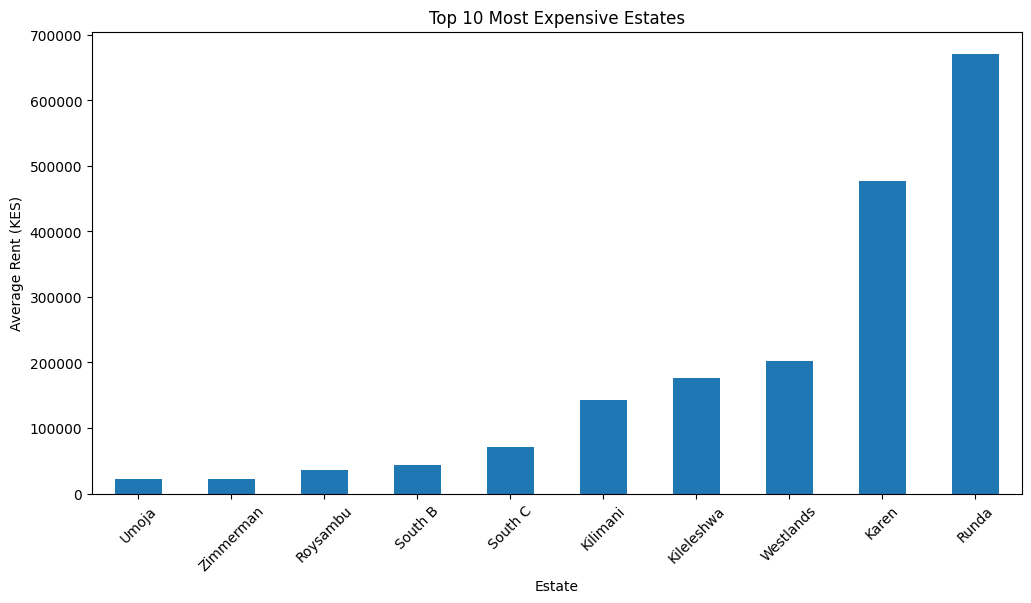

In [39]:
#plotting the most expensive estates
plt.figure(figsize=(12,6))

estate_prices.tail(10).plot(kind="bar")

plt.title("Top 10 Most Expensive Estates")
plt.ylabel("Average Rent (KES)")
plt.xlabel("Estate")
plt.xticks(rotation=45)

plt.show()

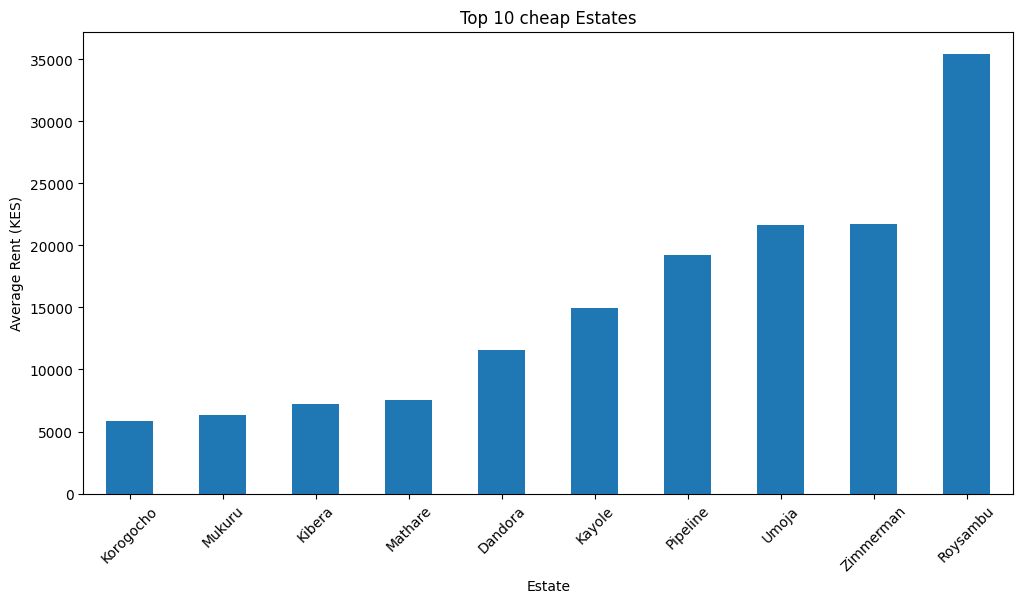

In [42]:
#plotting the cheapest
plt.figure(figsize=(12,6))

estate_prices.head(10).plot(kind="bar")

plt.title("Top 10 cheap Estates")
plt.ylabel("Average Rent (KES)")
plt.xlabel("Estate")
plt.xticks(rotation=45)

plt.show()

In [43]:
#Rent by subcounties
subcounty_prices = (
    data.groupby("SubCounty")["Rent_KES"]
    .mean()
    .sort_values(ascending=False)
)

print(subcounty_prices)

SubCounty
Westlands           425006.024096
Langata             203295.632699
Dagoretti North     158956.993918
Roysambu             28913.863823
Embakasi West        21678.253119
Embakasi East        19265.224359
Embakasi Central     14989.057239
Embakasi North       11592.727273
Kibra                 7189.097104
Ruaraka               6662.640207
Embakasi South        6350.082372
Name: Rent_KES, dtype: float64


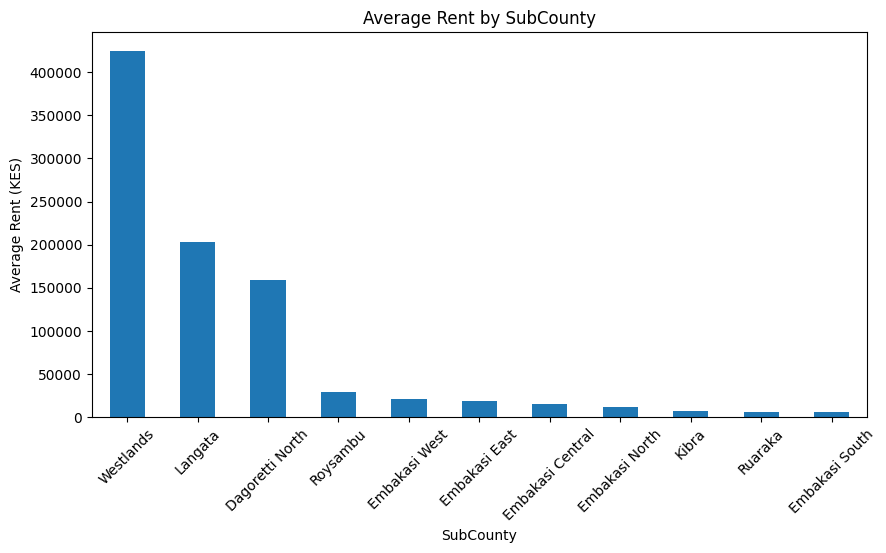

In [44]:
#plotting rent by each sub
plt.figure(figsize=(10,5))

subcounty_prices.plot(kind="bar")

plt.title("Average Rent by SubCounty")
plt.ylabel("Average Rent (KES)")
plt.xticks(rotation=45)

plt.show()

In [108]:
#rent by property type
property_prices = (
    data.groupby("Property_Type")["Rent_KES"]
    .mean()
    .sort_values(ascending=False)
)

print(property_prices)

Property_Type
Villa          838904.452690
Maisonette     364547.936085
Apartment       91826.029913
Studio          19443.283582
Bedsitter       10522.702991
Single Room      5193.242442
Name: Rent_KES, dtype: float64


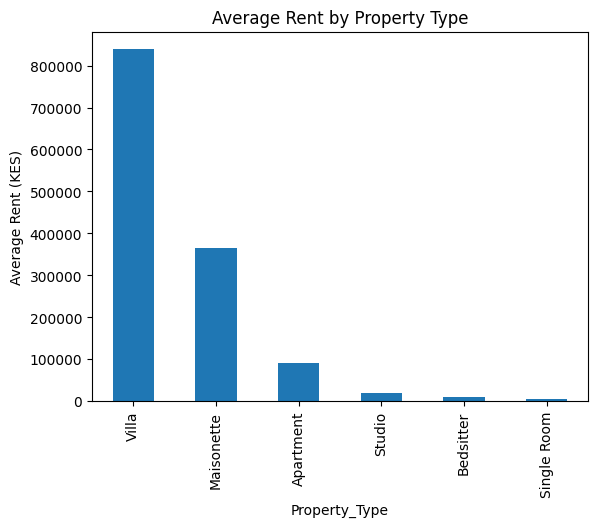

In [48]:
#plot rent by property type
property_prices.plot(kind="bar")

plt.title("Average Rent by Property Type")
plt.ylabel("Average Rent (KES)")

plt.show()

In [50]:
#rent by bedrooms
bedroom_prices = (
    data.groupby("Bedrooms")["Rent_KES"]
    .mean()
    .sort_values(ascending=False)
)

print(bedroom_prices)

Bedrooms
6    831760.355030
5    565284.738041
4    337814.199396
3    218480.745342
2     80078.571429
1     21565.278101
0      5193.242442
Name: Rent_KES, dtype: float64


In [53]:
#correlation between numeric variables
corr = data[["Rent_KES","Bedrooms","Bathrooms"]].corr()
print(corr)

           Rent_KES  Bedrooms  Bathrooms
Rent_KES   1.000000  0.782755   0.808956
Bedrooms   0.782755  1.000000   0.970103
Bathrooms  0.808956  0.970103   1.000000


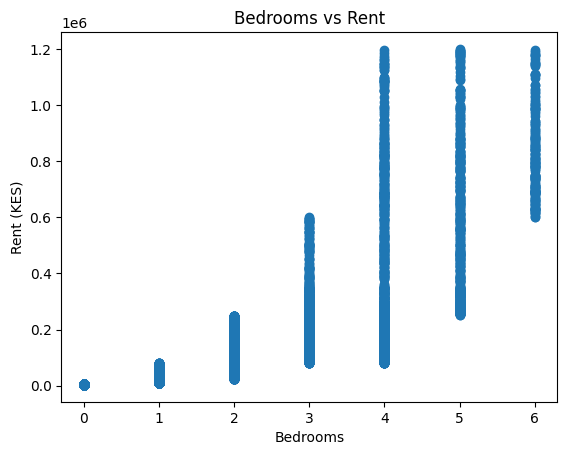

In [54]:
plt.scatter(data["Bedrooms"], data["Rent_KES"])

plt.title("Bedrooms vs Rent")
plt.xlabel("Bedrooms")
plt.ylabel("Rent (KES)")

plt.show()

In [68]:
#used for linear regression
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
data["log_rent"]=np.log(data["Rent_KES"])

In [69]:
#creating dummy variables
data_model = pd.get_dummies(
    data,
    columns=["Estate", "SubCounty", "Ward", "Property_Type"],
    drop_first=True
)

In [70]:
#we define x and y (the independent and dependent)
X = data_model.drop(columns=["ID", "log_rent"])

y = data_model["log_rent"]

In [71]:
#Split our data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)  #80% of the data is for training and 20% for testing

In [72]:
#training our model
model = LinearRegression()

model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [73]:
#make predictions
y_pred = model.predict(X_test)
print(y_pred)

[10.62019118  8.46130834 10.68899075 ...  9.18835862 12.61070321
  9.18211742]


In [74]:
#evaluation of the model
print("R² Score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

R² Score: 0.9775814667356187
MAE: 0.17647642937119193
RMSE: 0.22559964861076437


In [75]:
#rent distribution
data["log_rent"].describe()

count    10000.000000
mean        10.438585
std          1.526047
min          7.824046
25%          9.210340
50%         10.146434
75%         11.626254
max         13.997832
Name: log_rent, dtype: float64

In [88]:
#compare the actual prices vs the predicted
comparison = pd.DataFrame({
    "Actual Rent": y_test,
    "Predicted Rent": y_pred
})

comparison.head(10)

,Actual Rent,Predicted Rent
6252,10.558414,10.620191
4684,8.779557,8.461308
1731,10.292146,10.688991
4742,10.357743,10.400910
4521,11.231888,10.988088
6340,12.741103,12.846455
576,11.575900,11.732546
5202,8.612503,8.458188
6363,9.825526,9.844972
439,12.904207,12.938366


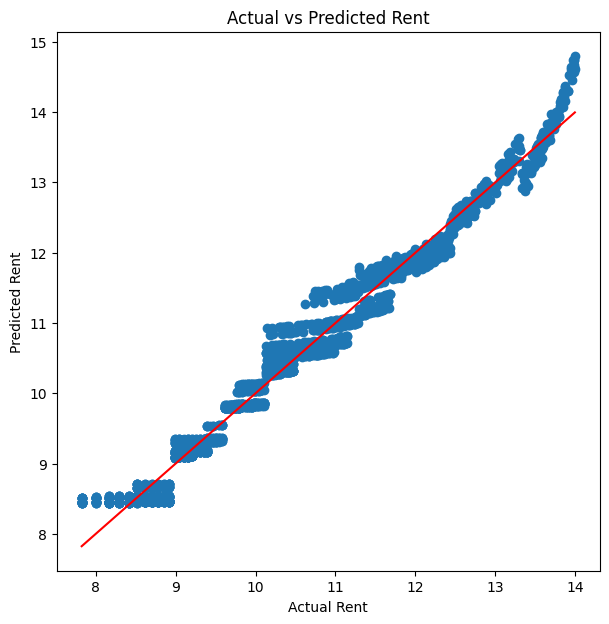

In [89]:
#scatter plot of the actual vs the predicted
import matplotlib.pyplot as plt

plt.figure(figsize=(7,7))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Rent")
plt.ylabel("Predicted Rent")
plt.title("Actual vs Predicted Rent")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red"
)

plt.show()

In [90]:
#view the regression coefficients
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

coefficients.sort_values(by="Coefficient", ascending=False).head(20)

,Feature,Coefficient
1,Bedrooms,0.542201
31,Ward_Kileleshwa,0.360466
6,Estate_Kileleshwa,0.360466
28,SubCounty_Westlands,0.336384
7,Estate_Kilimani,0.329801
32,Ward_Kilimani,0.329801
29,Ward_Karen,0.280084
3,Estate_Karen,0.280084
25,SubCounty_Langata,0.210425
39,Ward_Parklands,0.186653


In [91]:
coefficients.tail(20)

,Feature,Coefficient
29,Ward_Karen,0.280084
30,Ward_Kayole,-0.088536
31,Ward_Kileleshwa,0.360466
32,Ward_Kilimani,0.329801
33,Ward_Kitisuru,0.149732
34,Ward_Korogocho,-0.142750
35,Ward_Kwa Njenga,-0.171586
36,Ward_Laini Saba,-0.152261
37,Ward_Mathare North,-0.097156
38,Ward_Nairobi West,0.028279


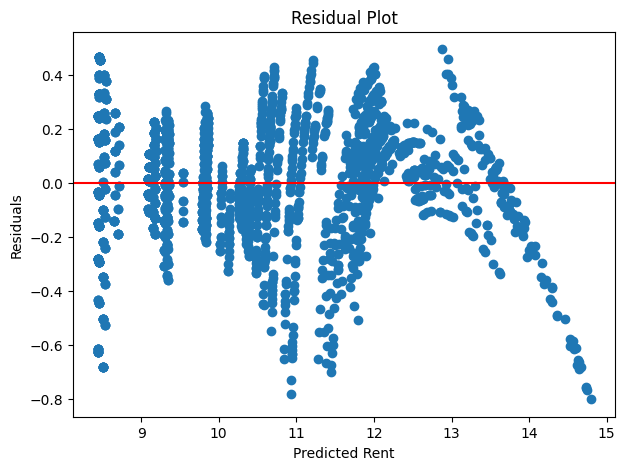

In [92]:
#check model assumptions
residuals = y_test - y_pred

plt.figure(figsize=(7,5))

plt.scatter(y_pred, residuals)

plt.axhline(y=0, color="red")

plt.xlabel("Predicted Rent")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.show()

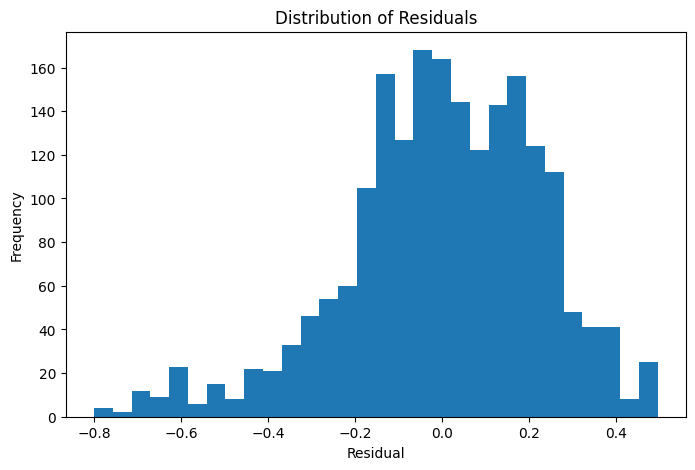

In [93]:
#plotting histogram of the residual
plt.figure(figsize=(8,5))

plt.hist(residuals, bins=30)

plt.title("Distribution of Residuals")
plt.xlabel("Residual")
plt.ylabel("Frequency")

plt.show()

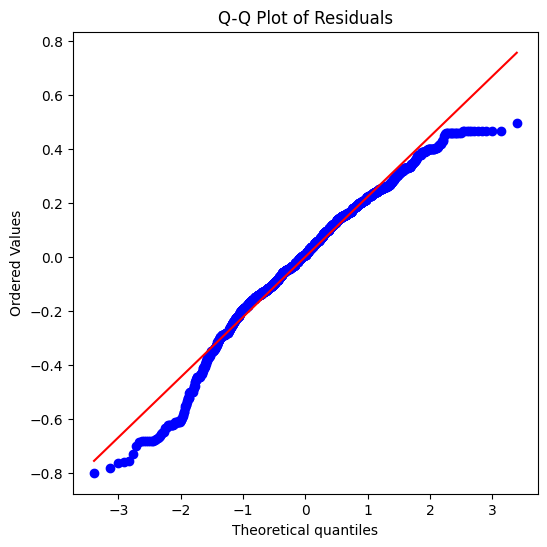

In [94]:
#q-q plot to check the normallity of the assumption
import scipy.stats as stats
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
stats.probplot(residuals, dist="norm", plot=plt)
plt.title("Q-Q Plot of Residuals")
plt.show()

In [104]:
#putting the predicted, actual and residual in 1 dataset
comparison2=pd.DataFrame({
    "Actual":y_test,
    "Predicted":y_pred,
    "Residuals":residuals
})
comparison2.head(10)

,Actual,Predicted,Residuals
6252,10.558414,10.620191,-0.061778
4684,8.779557,8.461308,0.318249
1731,10.292146,10.688991,-0.396845
4742,10.357743,10.400910,-0.043167
4521,11.231888,10.988088,0.243799
6340,12.741103,12.846455,-0.105352
576,11.575900,11.732546,-0.156646
5202,8.612503,8.458188,0.154316
6363,9.825526,9.844972,-0.019446
439,12.904207,12.938366,-0.034159


In [105]:
#exporting prediction results
comparison2.to_csv("predictions2.csv", index=False)

In [106]:
#
coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

coef_df

,Feature,Coefficient
0,Rent_KES,0.000003
1,Bedrooms,0.542201
2,Bathrooms,-0.445316
3,Estate_Karen,0.280084
4,Estate_Kayole,-0.088536
5,Estate_Kibera,-0.152261
6,Estate_Kileleshwa,0.360466
7,Estate_Kilimani,0.329801
8,Estate_Korogocho,-0.142750
9,Estate_Mathare,-0.097156


In [107]:
#exporting the coefficients
coef_df.to_csv("coefficients.csv", index=False)